## Candidate Selector
Model for selecting the best candidate from 10 candidates fetched from DBpedia Lookup API

## Import libraries

In [1]:
import os
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from datetime import datetime
from sentence_transformers import SentenceTransformer, util, CrossEncoder
from fuzzywuzzy import fuzz
from nltk.tokenize import RegexpTokenizer
from concurrent.futures import ThreadPoolExecutor, as_completed

2025-06-22 19:48:56.072213: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-22 19:48:56.079458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750614536.088080  282523 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750614536.090720  282523 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750614536.098177  282523 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Download and extract cached calculations and requests from zip files

In [23]:
import gdown
import zipfile
import os

Two zip files are saved on Google Drive:

In [ ]:
gdown.download('https://drive.google.com/uc?id=1aDOSESjp1268EnA6mY1f60_M36-GILyH', 'cached_requests.zip', quiet=False)

In [ ]:
gdown.download('https://drive.google.com/uc?id=1KGDIRWM5R4zf5jb0FdD7A1M3pWc7BMjk', 'cached_calculations.zip', quiet=False)

In [20]:
def print_zip_content(input_zip):
    print("\nContents of the zip file:")
    try:
        with zipfile.ZipFile(input_zip, 'r') as zipf:
            zipf.printdir()
    except FileNotFoundError:
        print(f"Error: Zip file not found at {input_zip}")

def unzip_files(zip_file_path, extract_dir):
    """
    Extracts all files from a zip archive to a specified directory.

    Args:
        zip_file_path (str): The path to the zip file to be unzipped.
        extract_dir (str): The directory where the files will be extracted.
    """
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zipf:
            # Create the extraction directory if it doesn't exist
            os.makedirs(extract_dir, exist_ok=True)
            
            print_zip_content(zip_file_path)
            
            zipf.extractall(extract_dir)
            print(f"Successfully extracted {zip_file_path} to {extract_dir}")            
    except zipfile.BadZipFile:
        print(f"Error: {zip_file_path} is not a valid zip file.")
    except FileNotFoundError:
        print(f"Error: Zip file not found at {zip_file_path}")

In [21]:
# unzip cached calculations
input_zip_calculations = "cached_calculations.zip"
output_calculations = "cached_calculations"
unzip_files(input_zip_calculations, output_calculations)


Contents of the zip file:
File Name                                             Modified             Size
cached_calculations/test_aida_golden_annotations_scored.csv 2025-06-21 19:19:18     72678996
cached_calculations/aida_scored_conll_20250424_200707.csv 2025-06-21 19:22:54     59477391
cached_calculations/aida_train_with_NER_FEWNERD_scored_fewnerd_20250424_192450.csv 2025-06-21 19:33:50    153161142
cached_calculations/test_ace_golden_annotations_scored.csv 2025-06-21 19:17:56      2714297
cached_calculations/aida_train_golden_annotations_with_candidates_scored_data_20250424_112539.csv 2025-06-21 19:26:54    342940333
cached_calculations/ace_scored_ontonotes_20250424_203134.csv 2025-06-21 19:20:10      2016028
cached_calculations/aida_scored_ontonotes_20250424_201839.csv 2025-06-21 19:22:04     36289879
cached_calculations/aida_train_with_NER_ONTONOTES_scored_ontonotes_20250424_184123.csv 2025-06-21 19:34:14    146923433
cached_calculations/ace_scored_fewnerd_20250424_203220.csv 20

In [22]:
# unzip cached requests
input_zip_requests = "cached_requests.zip"
output_requests = "cached_requests"
unzip_files(input_zip_requests, output_requests)


Contents of the zip file:
File Name                                             Modified             Size
cached_requests/ace2004_full_span-marker-roberta-large-ontonotes5_20250424_194220.json 2025-06-21 19:38:28      1840981
cached_requests/ace2004_full_span-marker-xlm-roberta-large-conllpp-doc-context_20250424_194152.json 2025-06-21 19:38:28      2034878
cached_requests/aida_train_golden_annotations_with_candidates.json 2025-06-21 19:38:28    194541114
cached_requests/ace2004_full_span-marker-bert-base-fewnerd-fine-super_20250424_194229.json 2025-06-21 19:38:28      1730994
cached_requests/ace_test_golden_annotations_with_candidates.json 2025-06-21 19:38:28      2871793
cached_requests/aida_train_converted_span-marker-roberta-large-ontonotes5_20250424_152828.json 2025-06-21 19:38:28    107531175
cached_requests/aida_test_full_span-marker-xlm-roberta-large-conllpp-doc-context_20250424_194021.json 2025-06-21 19:38:28     38638389
cached_requests/aida_test_golden_annotations_with_candi

## Candidate Selector using 4 contextual features

### Candidates Scorers

Define and initialize four scorers:
- context scorer
- levenshtein scorer
- popularity scorer
- position scorer

In [20]:
import torch
from sentence_transformers import SentenceTransformer, util, CrossEncoder
from fuzzywuzzy import fuzz
import numpy as np
from nltk.tokenize import RegexpTokenizer
import pandas as pd
from datetime import datetime


# Define scorers:
class ContextScorerBi:
    def __init__(self, model_name="sentence-transformers/all-mpnet-base-v2", round_to=3, device='cuda'):
        self.device = device if torch.cuda.is_available() else 'cpu'
        self.model = SentenceTransformer(model_name).to(self.device)
        self.round_to = round_to

    def score(self, context_text, candidate_comment):
        context_emb = self.model.encode(context_text, convert_to_tensor=True)
        candidate_emb = self.model.encode(candidate_comment, convert_to_tensor=True)
        score = util.pytorch_cos_sim(context_emb, candidate_emb).item()
        return round(score, self.round_to)

class LevenshteinDistanceScorer:
    def __init__(self, round_to=3):
        self.round_to = round_to

    def score(self, label1, label2):
        # Using token_sort_ratio for better handling of word order variations
        return round(fuzz.ratio(label1, label2) / 100.0, self.round_to)
        
class PopularityScorer:
    def __init__(self, round_to=3):
        self.round_to = round_to
        self.min_log_ref_count = None
        self.max_log_ref_count = None

    def fit(self, candidates):
        """Calculates min and max log popularity scores for normalization."""
        ref_counts = [c.get("ref_count", 0) for c in candidates]
        log_counts = np.log1p(ref_counts)
        self.min_log_ref_count = np.min(log_counts) if log_counts.size > 0 else 0
        self.max_log_ref_count = np.max(log_counts) if log_counts.size > 0 else 1 # Avoid division by zero

    def score(self, candidate):
        """scorers a single candidate based on popularity."""
        ref_count = candidate.get("ref_count", 0)
        log_val = np.log1p(ref_count)
        if self.max_log_ref_count == self.min_log_ref_count:
            return round(1.0, self.round_to)
        else:
            normalized = (log_val - self.min_log_ref_count) / (self.max_log_ref_count - self.min_log_ref_count)
            return round(normalized, self.round_to)

    def score_all(self, candidates):
        """scorers all candidates (using the fit method for normalization)."""
        self.fit(candidates)
        return [self.score(c) for c in candidates]

class DbpediaCandidatePositionScorer:
    def __init__(self, round_to=3, max_candidates=10):
        """
        Initializes the DbpediaCandidatePositionScorer.

        Args:
            round_to (int): The number of decimal places to round the score to.
            max_candidates (int): The maximum number of candidates expected.
        """
        self.round_to = round_to
        self.max_candidates = max_candidates

    def score_all(self, candidates):
        """
        Returns a list of raw (1-based) indices (positions) for all candidates.

        Args:
            candidates (list): A list of candidate objects.

        Returns:
            list: A list of 1-based indices corresponding to each candidate's position.
        """
        raw_scores = []
        for i, _ in enumerate(candidates):
            raw_scores.append(i + 1)  # Candidate object not needed for this score
        return raw_scores

    def normalize_score(self, raw_scores):
        """
        Inverts and normalizes the raw position scores to the range [0, 1].

        Args:
            raw_scores (list): A list of raw (1-based) position scores.

        Returns:
            list: A list of normalized position scores.
        """
        if not raw_scores:
            return []

        df = pd.DataFrame({'score_position': raw_scores})
        min_pos = df['score_position'].min()  # Should be 1
        max_pos = df['score_position'].max()  # Should be the number of candidates

        # Handle the case where there's only one candidate
        if max_pos == min_pos:
            normalized_scores = pd.Series([1.0] * len(raw_scores))
        else:
            normalized_scores = (max_pos - df['score_position']) / (max_pos - min_pos)

        return normalized_scores.round(self.round_to).tolist()

# ========== Initialize Scorers ==========
context_scorer_bi = ContextScorerBi()
levenshtein_scorer = LevenshteinDistanceScorer()
popularity_scorer = PopularityScorer()
position_scorer = DbpediaCandidatePositionScorer()


### Training Data Preparation

#### Analyse train data contents

Directories with saved calculations and requests:

In [7]:
output_calculations = "cached_calculations"
output_requests = "cached_requests"

Check the contents of the imported json file with saved requests results:

In [9]:
import json
json_file_path = os.path.join(output_requests + "/aida_train_golden_annotations_with_candidates.json")

# Load the JSON data
with open(json_file_path, "r", encoding="utf-8") as file:
    data = json.load(file)

# Show top-level structure
print("Keys in loaded JSON:")
print(data.keys())

# Access configuration
print("\nConfiguration:")
print(data["configuration"])

# Access one golden annotation entry
counter = len(data["named_entities_annotations"])
print(f"len of Golden Ann. {counter}")
print("\nSample Golden Annotation:")
print(json.dumps(data["named_entities_annotations"][0], indent=2))

# Access one prediction entry and its candidates
print("\nSample Prediction with Candidates:")
print(json.dumps(data["predictions"][0], indent=2))

golden_annotations = data["named_entities_annotations"]
predictions = data["predictions"]

Keys in loaded JSON:
dict_keys(['name', 'configuration', 'named_entities_annotations', 'predictions'])

Configuration:
{'dataset_path': './EvaluationDatasets/aida_train_converted.json', 'dataset_total_texts': 940, 'dataset_total_mentions': 18395, 'ned_knowledge_graph': 'dbpedia', 'use_golden_annotations': True, 'ner_model_name': None, 'ner_accuracy': 'N/A'}
len of Golden Ann. 940

Sample Golden Annotation:
{
  "content": "EU rejects German call to boycott British lamb . Peter Blackburn BRUSSELS 1996-08-22 The European Commission said on Thursday it disagreed with German advice to consumers to shun British lamb until scientists determine whether mad cow disease can be transmitted to sheep . Germany 's representative to the European Union 's veterinary committee Werner Zwingmann said on Wednesday consumers should buy sheepmeat from countries other than Britain until the scientific advice was clearer . \" We do n't support any such recommendation because we do n't see any grounds for it ,

Plot the Distribution of Candidates with No Ontology Types per Entity - AIDA train set


Average percentage of candidates without ontology types: 30.45%




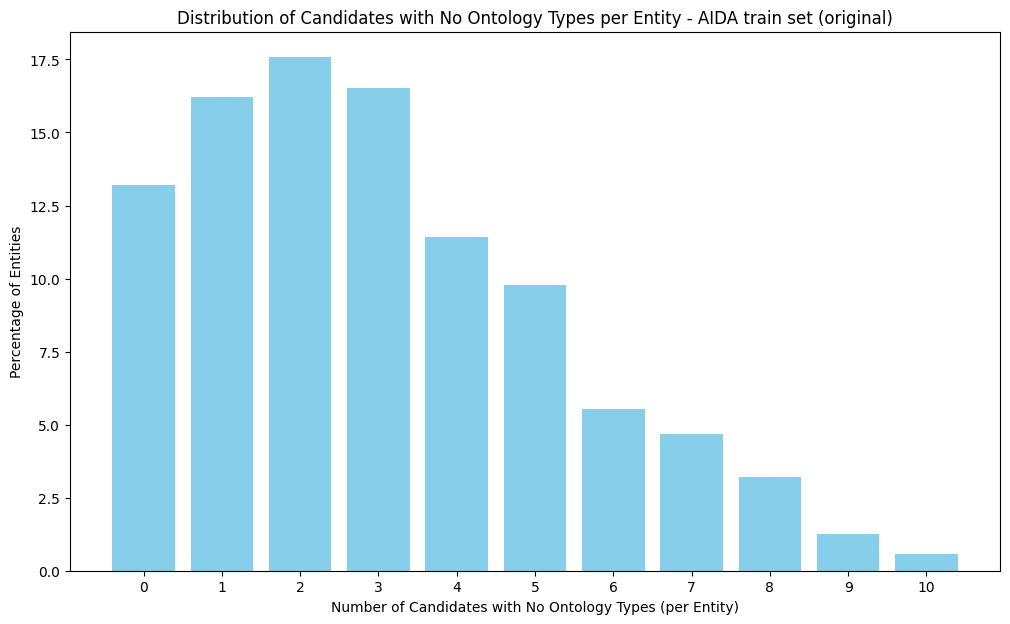

In [10]:
import json
import matplotlib.pyplot as plt
from collections import Counter


# Analysis
total_candidates_overall = 0
count_no_ontology_overall = 0
entity_no_ontology_counts = []

for entity_prediction in predictions:
    for entity in entity_prediction.get("entities", []):
        no_ontology_count = 0
        candidates = entity.get("candidates", [])
        total_candidates = len(candidates)
        total_candidates_overall += total_candidates
        for candidate in candidates:
            ontology_types = candidate.get("ontology_types", [])
            if not ontology_types:
                no_ontology_count += 1
                count_no_ontology_overall += 1
        entity_no_ontology_counts.append(no_ontology_count)

# Calculate the average percentage of candidates without ontology types
average_percent_no_ontology = (count_no_ontology_overall / total_candidates_overall) * 100 if total_candidates_overall > 0 else 0
print(f"\nAverage percentage of candidates without ontology types: {average_percent_no_ontology:.2f}%\n\n")


# Count the occurrences of each no_ontology_count
no_ontology_distribution = Counter(entity_no_ontology_counts)
total_entities = len(entity_no_ontology_counts)

# Prepare data for plotting
x_values = range(11)  # 0 to 10
y_values = [(no_ontology_distribution[i] / total_entities) * 100 if total_entities > 0 else 0 for i in x_values]

# Visualization
plt.figure(figsize=(12, 7))  # Adjusted figure size for better label visibility
plt.bar(x_values, y_values, color="skyblue")
plt.xlabel("Number of Candidates with No Ontology Types (per Entity)")
plt.ylabel("Percentage of Entities")
plt.title("Distribution of Candidates with No Ontology Types per Entity - AIDA train set (original)")
plt.xticks(x_values)  # Ensure all x-axis values are shown

plt.show()

#### Train Data - Scoring of candidates

In [21]:
def score_candidate_predictions(predictions, dataset_name="Dataset"):
    """
    scorers candidates for each entity mention in the predictions using multiple scoring strategies.
    
    Parameters:
        predictions (List[Dict]): A list of annotated entries with entity candidates.
        dataset_name (str): Optional name of the dataset (for logging).
    
    Returns:
        pd.DataFrame: Scored DataFrame with features for each candidate.
    """
    scored_data = []

    for entry in tqdm(predictions, desc=f"Scoring predictions for {dataset_name}"):
        context_text = entry["content"]
        for entity in entry["entities"]:
            entity_label = entity["entity_label"]
            start_position = entity["start_position"]
            end_position = entity["end_position"]
            candidates = entity["candidates"]

            # Batch scoring
            pop_scores = popularity_scorer.score_all(candidates)
            pos_scores_raw = list(range(1, len(candidates) + 1))
            normalized_pos_scores = position_scorer.normalize_score(pos_scores_raw)

            for i, candidate in enumerate(candidates):
                label = candidate["label"]
                comment = candidate.get("comment", "")

                score_lev = levenshtein_scorer.score(entity_label, label)
                score_ctx_bi = context_scorer_bi.score(context_text, comment)
                score_pop = pop_scores[i]
                score_pos = normalized_pos_scores[i]

                scored_data.append({
                    "context_text": context_text,
                    "entity_label": entity_label,
                    "start_position": start_position,
                    "end_position": end_position,
                    "candidate_label": label,
                    "candidate_uri": candidate["uri"],
                    "score_levenshtein": score_lev,
                    "score_context_bi": score_ctx_bi,
                    "score_popularity": score_pop,
                    "score_position": score_pos,
                })

    df = pd.DataFrame(scored_data)
    return df

In [ ]:
train_df = score_candidate_predictions(predictions, dataset_name="AIDA Training")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

csv_filename = f'aida_train_golden_annotations_with_candidates_scored_data_{timestamp}.csv'
train_df.to_csv(csv_filename, index=False)

print(f"DataFrame saved to {csv_filename}")

#### Train Data - Import scored candidates from cached calculations

In [12]:
train_df = pd.read_csv(output_calculations + "/aida_train_golden_annotations_with_candidates_scored_data_20250424_112539.csv")

In [13]:
train_df.head()

,context_text,entity_label,start_position,end_position,candidate_label,candidate_uri,score_levenshtein,score_context_bi,score_popularity,score_dbpedia,score_position
0,EU rejects German call to boycott British lamb...,German,11,17,German Empire,http://dbpedia.org/resource/German_Empire,0.63,0.072,0.566,1.000,1.000
1,EU rejects German call to boycott British lamb...,German,11,17,German language,http://dbpedia.org/resource/German_language,0.57,0.111,0.577,1.000,0.889
2,EU rejects German call to boycott British lamb...,German,11,17,Germany,http://dbpedia.org/resource/Germany,0.92,0.175,1.000,0.811,0.778
3,EU rejects German call to boycott British lamb...,German,11,17,West Germany,http://dbpedia.org/resource/West_Germany,0.67,0.098,0.637,0.452,0.667
4,EU rejects German call to boycott British lamb...,German,11,17,Nazi Germany,http://dbpedia.org/resource/Nazi_Germany,0.67,0.100,0.546,0.352,0.556


In [14]:
train_df.describe()

,start_position,end_position,score_levenshtein,score_context_bi,score_popularity,score_dbpedia,score_position
count,183868.000000,183868.000000,183868.000000,183868.000000,183868.000000,183868.000000,183868.000000
mean,823.993947,832.981791,0.472527,0.188663,0.381425,0.310885,0.500000
std,899.588983,899.728480,0.270146,0.176217,0.339219,0.323202,0.319278
min,0.000000,3.000000,0.000000,-0.208000,0.000000,0.000000,0.000000
25%,212.000000,221.000000,0.260000,0.042000,0.075000,0.049000,0.222000
50%,544.000000,553.000000,0.460000,0.160000,0.293000,0.194000,0.500000
75%,1096.000000,1105.000000,0.650000,0.317000,0.638000,0.472000,0.778000
max,6887.000000,6895.000000,1.000000,0.843000,1.000000,1.000000,1.000000


#### Flag best candidate for each entity

In [17]:
def create_best_candidate_flag_grouped(predictions_df, golden_annotations):
    best_candidate_uris = {}
    for gold_entry in golden_annotations:
        for entity in gold_entry['entities']:
            key = (gold_entry['content'], entity['entity_label'], entity['start_position'], entity['end_position'])
            best_candidate_uris[key] = entity['best_candidate_uri']

    predictions_df['is_best_candidate'] = False
    for index, row in predictions_df.iterrows():
        key = (row['context_text'], row['entity_label'], row['start_position'], row['end_position'])
        if key in best_candidate_uris and row['candidate_uri'] == best_candidate_uris[key]:
            predictions_df.loc[index, 'is_best_candidate'] = True
    return predictions_df

In [ ]:
train_df_with_best_flag = create_best_candidate_flag_grouped(train_df.copy(), golden_annotations)

In [16]:
train_df_with_best_flag.head()

,context_text,entity_label,start_position,end_position,candidate_label,candidate_uri,score_levenshtein,score_context_bi,score_popularity,score_dbpedia,score_position,is_best_candidate
0,EU rejects German call to boycott British lamb...,German,11,17,German Empire,http://dbpedia.org/resource/German_Empire,0.63,0.072,0.566,1.000,1.000,False
1,EU rejects German call to boycott British lamb...,German,11,17,German language,http://dbpedia.org/resource/German_language,0.57,0.111,0.577,1.000,0.889,False
2,EU rejects German call to boycott British lamb...,German,11,17,Germany,http://dbpedia.org/resource/Germany,0.92,0.175,1.000,0.811,0.778,True
3,EU rejects German call to boycott British lamb...,German,11,17,West Germany,http://dbpedia.org/resource/West_Germany,0.67,0.098,0.637,0.452,0.667,False
4,EU rejects German call to boycott British lamb...,German,11,17,Nazi Germany,http://dbpedia.org/resource/Nazi_Germany,0.67,0.100,0.546,0.352,0.556,False


### Test Data Preparation

Prepare evaluation data - two datasets: AIDA and ACE2004

##### Helper functions

In [18]:
import pandas as pd
import json
from sklearn.metrics import accuracy_score, classification_report

def load_golden_and_predictions(filepath):
    with open(filepath, "r", encoding="utf-8") as file:
        data = json.load(file)
    return data["golden_annotations"], data["predictions"]
    
def describe_dataset(name, df):
    print(f"\n\n===== Dataset Description: {name} =====")
    print(df.describe()) 

def evaluate_dataset(name, df_scored, golden_annotations, rf_pipeline, max_candidates=10):
    print(f"\n===== Evaluating Dataset: {name} =====")

    # Flag best candidates
    df_flagged = create_best_candidate_flag_grouped(df_scored.copy(), golden_annotations)

    # Extract features and labels
    X_test, y_test = build_grouped_dataframe_rf(df_flagged, max_candidates=max_candidates)

    # Predict and evaluate
    y_pred = rf_pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n{name} - Test Accuracy (Random Forest): {accuracy:.4f}")
    print(f"{name} - Classification Report:\n", classification_report(y_test, y_pred))

    return accuracy

##### Import test datasets

In [47]:
test_json_file_path_aida = output_requests + "/aida_test_golden_annotations_with_candidates.json"
test_json_file_path_ace = output_requests + "/ace_test_golden_annotations_with_candidates.json"

test_golden_annotations_aida, test_predictions_aida = load_golden_and_predictions(test_json_file_path_aida)
test_golden_annotations_ace, test_predictions_ace = load_golden_and_predictions(test_json_file_path_ace)

#### Test Data - Scoring of candidates

In [152]:
test_df_aida = score_candidate_predictions(test_predictions_aida, dataset_name="AIDA Test")
test_df_ace = score_candidate_predictions(test_predictions_ace, dataset_name="ACE Test")

csf_filename_aida = output_calculations + "/test_aida_golden_annotations_scored.csv"
csf_filename_ace = output_calculations + "/test_ace_golden_annotations_scored.csv"

test_df_aida.to_csv(csf_filename_aida, index=False)
print(f"DataFrame saved to {csf_filename_aida}")

test_df_ace.to_csv(csf_filename_ace, index=False)
print(f"DataFrame saved to {csf_filename_ace}")

Scoring predictions for ACE Test: 100%|██████████| 119/119 [00:21<00:00,  5.60it/s]


DataFrame saved to test_aida_golden_annotations_scored.csv
DataFrame saved to test_ace_golden_annotations_scored.csv


#### Test Data - Import scored candidates from cached calculations

In [19]:
test_df_aida = pd.read_csv(output_calculations + "/test_aida_golden_annotations_scored.csv")
test_df_aida.drop(columns=["score_dbpedia"], inplace=True)
test_df_ace = pd.read_csv(output_calculations + "/test_ace_golden_annotations_scored.csv")
test_df_ace.drop(columns=["score_dbpedia"], inplace=True)

##### Analyse data contents

In [51]:
def count_entities(golden_annotations_list):
    """Counts the total number of entities in a list of golden annotations."""
    total_entities = 0
    for annotation in golden_annotations_list:
        entities = annotation.get('entities', [])
        total_entities += len(entities)
    return total_entities

number_of_entities_aida = count_entities(test_golden_annotations_aida)
print(f"Total number of entities in AIDA test set: {number_of_entities_aida}")

number_of_entities_ace = count_entities(test_golden_annotations_ace)
print(f"Total number of entities in AIDA test set: {number_of_entities_ace}")

Total number of entities in AIDA test set: 4463
Total number of entities in AIDA test set: 257


In [22]:
describe_dataset("AIDA", test_df_aida)
describe_dataset("ACE", test_df_ace)



===== Dataset Description: AIDA =====
       start_position  end_position  score_levenshtein  score_context_bi  \
count    44610.000000  44610.000000       44610.000000      44610.000000   
mean       730.298700    739.195091           0.460290          0.198159   
std        695.540818    695.532576           0.272301          0.169520   
min          0.000000      3.000000           0.000000         -0.170000   
25%        208.000000    218.000000           0.240000          0.062000   
50%        523.000000    532.000000           0.440000          0.180000   
75%       1059.000000   1065.000000           0.640000          0.310000   
max       4015.000000   4045.000000           1.000000          0.811000   

       score_popularity  score_position  
count      44610.000000    44610.000000  
mean           0.378351        0.500011  
std            0.339316        0.319268  
min            0.000000        0.000000  
25%            0.073000        0.222000  
50%            0.289000

In [64]:
test_df_ace.head()

,context_text,entity_label,start_position,end_position,candidate_label,candidate_uri,score_levenshtein,score_context_bi,score_popularity,score_position
0,Bandar Seri Begawan 11 15 AFP The United State...,Bandar Seri Begawan,0,19,Bandar Seri Begawan,http://dbpedia.org/resource/Bandar_Seri_Begawan,1.00,0.263,0.839,1.000
1,Bandar Seri Begawan 11 15 AFP The United State...,Bandar Seri Begawan,0,19,"Pusat Bandar, Brunei","http://dbpedia.org/resource/Pusat_Bandar,_Brunei",0.46,0.275,0.289,0.889
2,Bandar Seri Begawan 11 15 AFP The United State...,Bandar Seri Begawan,0,19,"Embassy of the Philippines, Bandar Seri Begawan",http://dbpedia.org/resource/Embassy_of_the_Phi...,0.58,0.349,0.124,0.778
3,Bandar Seri Begawan 11 15 AFP The United State...,Bandar Seri Begawan,0,19,1999 Southeast Asian Games,http://dbpedia.org/resource/1999_Southeast_Asi...,0.27,0.236,0.349,0.667
4,Bandar Seri Begawan 11 15 AFP The United State...,Bandar Seri Begawan,0,19,List of diplomatic missions of Russia,http://dbpedia.org/resource/List_of_diplomatic...,0.21,0.137,1.000,0.556


In [60]:
test_df_ace.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2570 entries, 0 to 2569
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   context_text       2570 non-null   object 
 1   entity_label       2570 non-null   object 
 2   start_position     2570 non-null   int64  
 3   end_position       2570 non-null   int64  
 4   candidate_label    2570 non-null   object 
 5   candidate_uri      2570 non-null   object 
 6   score_levenshtein  2570 non-null   float64
 7   score_context_bi   2570 non-null   float64
 8   score_popularity   2570 non-null   float64
 9   score_position     2570 non-null   float64
dtypes: float64(4), int64(2), object(4)
memory usage: 200.9+ KB


### Candidate Selector - XGBoost Trainig and Evaluation

Train XGBoost model using each possible combination of 4 features (scores). 

Training process using each configuration is repeated 3 times to minimize randomness.

Evaluate the trained XGboost model using the two test datasets. 

The average accuracy of predictions on these two test datasets should be maximised.

Top 10 models based on averaage prediction accuracy is saved on disk.

In [64]:
import pandas as pd
import numpy as np
import itertools
import json
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# === Constants ===
MAX_CANDIDATES = 10
METRIC_NAMES = ['levenshtein', 'context_bi', 'popularity', 'position']
N_REPEATS_PER_CONFIG = 3
TOP_N_MODELS_TO_SAVE = 10

# === Feature and Target Builder ===
def build_grouped_dataframe_xgb(df, selected_metrics, max_candidates=MAX_CANDIDATES):
    grouped_features = []
    targets = []

    selected_feature_columns = [f"score_{m}" for m in selected_metrics]

    for _, group in df.groupby(['context_text', 'entity_label', 'start_position', 'end_position']):
        candidates = group[selected_feature_columns].values

        if len(candidates) < max_candidates:
            pad = np.zeros((max_candidates - len(candidates), candidates.shape[1]))
            candidates = np.vstack([candidates, pad])
        elif len(candidates) > max_candidates:
            candidates = candidates[:max_candidates]

        best_idx = group['is_best_candidate'].values.argmax()
        grouped_features.append(candidates.flatten().astype(np.float32))
        targets.append(best_idx)

    X = np.stack(grouped_features)
    y = np.array(targets)
    return X, y

# === Model Training Function ===
def train_xgb(X_train, y_train):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', XGBClassifier(
            eval_metric='mlogloss',
            n_jobs=-1,
            verbosity=0
        ))
    ])
    pipeline.fit(X_train, y_train)
    return pipeline

# === Evaluation Functions ===
def load_golden_and_predictions(filepath):
    with open(filepath, "r", encoding="utf-8") as file:
        data = json.load(file)
    return data["golden_annotations"], data["predictions"]

def create_best_candidate_flag_grouped(predictions_df, golden_annotations):
    best_candidate_uris = {}
    for gold_entry in golden_annotations:
        for entity in gold_entry['entities']:
            key = (gold_entry['content'], entity['entity_label'], entity['start_position'], entity['end_position'])
            best_candidate_uris[key] = entity['best_candidate_uri']

    predictions_df['is_best_candidate'] = False
    for index, row in predictions_df.iterrows():
        key = (row['context_text'], row['entity_label'], row['start_position'], row['end_position'])
        if key in best_candidate_uris and row['candidate_uri'] == best_candidate_uris[key]:
            predictions_df.at[index, 'is_best_candidate'] = True
    return predictions_df

def evaluate_dataset(name, df_scored, golden_annotations, xgb_pipeline, selected_metrics):
    df_flagged = create_best_candidate_flag_grouped(df_scored.copy(), golden_annotations)
    X_test, y_test = build_grouped_dataframe_xgb(df_flagged, selected_metrics)

    y_pred = xgb_pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# === Overall Process ===
def feature_selection_and_training(train_df, test_aida_df, test_golden_aida, test_ace_df, test_golden_ace):
    all_results = []
    feature_combinations = []

    for r in range(1, len(METRIC_NAMES) + 1):
        feature_combinations.extend(itertools.combinations(METRIC_NAMES, r))

    for feature_set in feature_combinations:
        selected_features = list(feature_set)
        print(f"\n🔵 Training with features: {selected_features}")

        # Prepare training data
        X_xgb, y_xgb = build_grouped_dataframe_xgb(train_df, selected_features)

        for repeat_idx in range(N_REPEATS_PER_CONFIG):
            print(f"    ➡️ Repetition {repeat_idx+1}/{N_REPEATS_PER_CONFIG}")

            X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2)

            xgb_pipeline = train_xgb(X_train_xgb, y_train_xgb)

            # Validation evaluation
            y_pred_val_xgb = xgb_pipeline.predict(X_val_xgb)
            val_accuracy = accuracy_score(y_val_xgb, y_pred_val_xgb)

            # Test datasets evaluation
            acc_aida = evaluate_dataset("AIDA", test_aida_df, test_golden_aida, xgb_pipeline, selected_features)
            acc_ace = evaluate_dataset("ACE", test_ace_df, test_golden_ace, xgb_pipeline, selected_features)

            avg_test_accuracy = (acc_aida + acc_ace) / 2

            result = {
                'features': selected_features,
                'repeat_idx': repeat_idx,
                'val_accuracy': val_accuracy,
                'test_acc_aida': acc_aida,
                'test_acc_ace': acc_ace,
                'avg_test_accuracy': avg_test_accuracy,
                'model': xgb_pipeline
            }
            all_results.append(result)

    return all_results

In [20]:
# === Execute the Process ===
all_results = feature_selection_and_training(
    train_df_with_best_flag,
    test_df_aida, test_golden_annotations_aida,
    test_df_ace, test_golden_annotations_ace
)

# === Save Top N Best models ===
sorted_results = sorted(all_results, key=lambda x: x['avg_test_accuracy'], reverse=True)
top_results = sorted_results[:TOP_N_MODELS_TO_SAVE]

for idx, res in enumerate(top_results):
    filename = f"best_xgb_model_{idx+1}_acc_{res['avg_test_accuracy']:.4f}.pkl"
    joblib.dump(res['model'], filename)
    print(f"✅ Saved {filename} with features {res['features']} (repeat {res['repeat_idx']}) and avg test acc {res['avg_test_accuracy']:.4f}")

# === Summary of Top models ===
print("\n=== Top Model Results Summary ===")
for idx, res in enumerate(top_results):
    print(f"#{idx+1}: Features: {res['features']}, Repeat: {res['repeat_idx']}, Val Acc: {res['val_accuracy']:.4f}, AIDA Test Acc: {res['test_acc_aida']:.4f}, ACE Test Acc: {res['test_acc_ace']:.4f}, Avg Test Acc: {res['avg_test_accuracy']:.4f}")


🔵 Training with features: ['levenshtein']
    ➡️ Repetition 1/3
    ➡️ Repetition 2/3
    ➡️ Repetition 3/3

🔵 Training with features: ['context_bi']
    ➡️ Repetition 1/3
    ➡️ Repetition 2/3
    ➡️ Repetition 3/3

🔵 Training with features: ['popularity']
    ➡️ Repetition 1/3
    ➡️ Repetition 2/3
    ➡️ Repetition 3/3

🔵 Training with features: ['position']
    ➡️ Repetition 1/3
    ➡️ Repetition 2/3
    ➡️ Repetition 3/3

🔵 Training with features: ['dbpedia']
    ➡️ Repetition 1/3
    ➡️ Repetition 2/3
    ➡️ Repetition 3/3

🔵 Training with features: ['levenshtein', 'context_bi']
    ➡️ Repetition 1/3
    ➡️ Repetition 2/3
    ➡️ Repetition 3/3

🔵 Training with features: ['levenshtein', 'popularity']
    ➡️ Repetition 1/3
    ➡️ Repetition 2/3
    ➡️ Repetition 3/3

🔵 Training with features: ['levenshtein', 'position']
    ➡️ Repetition 1/3
    ➡️ Repetition 2/3
    ➡️ Repetition 3/3

🔵 Training with features: ['levenshtein', 'dbpedia']
    ➡️ Repetition 1/3
    ➡️ Repetition 2/3

## Candidate Selector using 4 contextual and 3 embedding-based features

### NER types definitions
Needed for embedding-based features calculations

In [25]:
CLASS_DEFINITIONS = {
        "tomaarsen/span-marker-xlm-roberta-large-conllpp-doc-context": {
            "PER": "PER - Proper names of individuals, including first names, last names, fictional names, and unique nicknames.",
            "LOC": "LOC - Names of geographical locations such as cities, countries, states, provinces, and other physical locations.",
            "ORG": "ORG - Names of organizations including companies, government agencies, political parties, educational institutions, and sports teams.",
            "MISC": "MISC - Other named entities that do not fit into PER, LOC, or ORG categories, such as nationalities, artistic works, events, and other miscellaneous proper nouns.",
        },
        "tomaarsen/span-marker-roberta-large-ontonotes5": {
            "PERSON": "PERSON - Proper names of people including first names, last names, individual or family names, fictional names and unique nicknames.",
            "NORP": "NORP - Adjectival forms of GPE and non-GPE place names (such as American), named religions, heritage, and political affiliation.",
            "FAC": "FAC - Names of man-made structures, including the buildings, airports, stations, infrastructures (bridges and streets), monuments, oil fields, golf courses, hospitals, zoos, shopping centers, etc.",
            "ORG": "ORG - Names of companies, government agencies, political parties, educational institutions, sport teams, hospitals, museums, libraries etc.",
            "GPE": "GPE - Names of geographical administrative entities including countries, villages, cities, states, provinces, prefectures, and other forms of municipalities",
            "LOC": "LOC - Names of locations other than GPEs including celestial bodies, stars, continents, mountains, oceans, coasts, rivers, lakes, borders, etc.",
            "PRODUCT": "PRODUCT - Name of any product including non-commercial vehicles (automobiles, rockets, aircraft, ships).",
            "EVENT": "EVENT - Named events and phenomena including natural disasters, hurricanes, revolutions, battles, wars, demonstrations, concerts, sports events, etc.",
            "WORK_OF_ART": "WORK OF ART - Titles of books, songs, films, plays and other creations such as awards, stock price indexes, and social security systems including health insurance systems or pension plans.",
            "LAW": "LAW - Named legal documents including laws, treaties, sections, and chapters.",
            "LANGUAGE": "LANGUAGE - Any named language including programming languages.",
        },
        "tomaarsen/span-marker-bert-base-fewnerd-fine-super": {
            "art-broadcastprogram": "art-broadcastprogram - Broadcast programs including TV and radio shows.",
            "art-film": "art-film - Film titles and cinematic works.",
            "art-music": "art-music - Music-related works including performances, bands, and symphonies.",
            "art-other": "art-other - Other artistic creations not covered by film, music, painting, or written art.",
            "art-painting": "art-painting - Titles of paintings and art reproductions.",
            "art-writtenart": "art-writtenart - Literary and written art forms, including books and scripts.",
            "building-airport": "building-airport - Names of airports and aviation terminals.",
            "building-hospital": "building-hospital - Hospitals and medical facilities.",
            "building-hotel": "building-hotel - Hotels and lodging establishments.",
            "building-library": "building-library - Libraries and book repositories.",
            "building-other": "building-other - Other types of buildings not categorized elsewhere.",
            "building-restaurant": "building-restaurant - Restaurants and dining establishments.",
            "building-sportsfacility": "building-sportsfacility - Sports facilities and arenas.",
            "building-theater": "building-theater - Theaters and performance venues.",
            "event-attack/battle/war/militaryconflict": "event-attack/battle/war/militaryconflict - Military conflicts including attacks, battles, wars, and military engagements.",
            "event-disaster": "event-disaster - Natural or man-made disasters and catastrophic events.",
            "event-election": "event-election - Elections and voting events.",
            "event-other": "event-other - Other events not classified elsewhere.",
            "event-protest": "event-protest - Protests and demonstrations.",
            "event-sportsevent": "event-sportsevent - Sports events and competitions.",
            "location-GPE": "location-GPE - Geopolitical entities, typically countries, states, or cities.",
            "location-bodiesofwater": "location-bodiesofwater - Names of significant bodies of water such as lakes, rivers, and coasts.",
            "location-island": "location-island - Names of islands and archipelagos.",
            "location-mountain": "location-mountain - Mountain ranges, peaks, and related geographical features.",
            "location-other": "location-other - Other location names not covered by standard geographical categories.",
            "location-park": "location-park - Parks and recreational areas.",
            "location-road/railway/highway/transit": "location-road/railway/highway/transit - Transportation-related locations such as roads, railways, highways, and transit systems.",
            "organization-company": "organization-company - Companies and corporate entities.",
            "organization-education": "organization-education - Educational institutions and organizations.",
            "organization-government/governmentagency": "organization-government/governmentagency - Government bodies and agencies.",
            "organization-media/newspaper": "organization-media/newspaper - Media organizations and newspaper titles.",
            "organization-other": "organization-other - Other organizational entities not covered by other categories.",
            "organization-politicalparty": "organization-politicalparty - Political parties and related organizations.",
            "organization-religion": "organization-religion - Religious organizations and groups.",
            "organization-showorganization": "organization-showorganization - Organizations related to shows, entertainment, and performance groups.",
            "organization-sportsleague": "organization-sportsleague - Sports leagues and associations.",
            "organization-sportsteam": "organization-sportsteam - Sports teams and clubs.",
            "other-astronomything": "other-astronomything - Celestial objects and astronomy-related terms.",
            "other-award": "other-award - Awards and honors.",
            "other-biologything": "other-biologything - Biological terms and entities.",
            "other-chemicalthing": "other-chemicalthing - Chemical substances and compounds.",
            "other-currency": "other-currency - Currency symbols or names.",
            "other-disease": "other-disease - Diseases and medical conditions.",
            "other-educationaldegree": "other-educationaldegree - Academic degrees and certifications.",
            "other-god": "other-god - Deities and divine entities.",
            "other-language": "other-language - Language names or linguistic entities.",
            "other-law": "other-law - Legal terms and law-related entities.",
            "other-livingthing": "other-livingthing - Living organisms and fauna.",
            "other-medical": "other-medical - Medical specialties, professionals, or terms.",
            "person-actor": "person-actor - Actors and performers in film, television, or theater.",
            "person-artist/author": "person-artist/author - Artists and authors.",
            "person-athlete": "person-athlete - Athletes and sports figures.",
            "person-director": "person-director - Film or stage directors.",
            "person-other": "person-other - Other persons not categorized elsewhere.",
            "person-politician": "person-politician - Politicians and political figures.",
            "person-scholar": "person-scholar - Scholars, researchers, and academics.",
            "person-soldier": "person-soldier - Military personnel and soldiers.",
            "product-airplane": "product-airplane - Aircraft and airplanes.",
            "product-car": "product-car - Cars and automobiles.",
            "product-food": "product-food - Food items or brands.",
            "product-game": "product-game - Games or video game titles.",
            "product-other": "product-other - Other products or merchandise.",
            "product-ship": "product-ship - Ships and maritime vessels.",
            "product-software": "product-software - Software products or applications.",
            "product-train": "product-train - Trains and railway vehicles.",
            "product-weapon": "product-weapon - Weapons and armaments.",
        }
}

### New scorers

In [19]:
import torch
import numpy as np
from sentence_transformers import SentenceTransformer, util

class TypesEmbeddingScorer:
    def __init__(self, ner_model_name=None, model_name="all-MiniLM-L6-v2", round_to_decimal_places=3, device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.embeddings_model = SentenceTransformer(model_name).to(self.device)
        self.round_to_decimal_places = round_to_decimal_places
        self.ner_model_name = ner_model_name

        self.class_definitions = CLASS_DEFINITIONS.get(ner_model_name, {})
        self.ner_embeddings_cache = {
            ner_type: self.get_embedding(definition)
            for ner_type, definition in self.class_definitions.items()
            if ner_type != "O"
        }
        print(f"Using {len(self.class_definitions)} classes")

    def get_embedding(self, sentence):
        return self.embeddings_model.encode(sentence, convert_to_tensor=True).to(self.device)

    def score_types_embedding(self, entity_probabilities: list, ontology_types: list) -> float:
        # print(f"ontology_types:{ontology_types}")
        # print(f"entity_probabilities:{entity_probabilities}")
        if not ontology_types or not entity_probabilities:
            return 0.0

        valid_ner_probabilities = [(cls, prob) for cls, prob in entity_probabilities if cls in self.ner_embeddings_cache]
        # print(f"valid_ner_probabilities:{valid_ner_probabilities}")

        if not valid_ner_probabilities:
            return 0.0

        ner_classes = [item[0] for item in valid_ner_probabilities]
        ner_probabilities = np.array([float(item[1]) for item in valid_ner_probabilities])

        kg_embeddings = {kg_type: self.get_embedding(kg_type) for kg_type in ontology_types}
        similarity_matrix = np.zeros((len(ner_classes), len(ontology_types)))

        for i, ner_cls in enumerate(ner_classes):
            ner_embedding = self.ner_embeddings_cache[ner_cls]
            for j, kg_type in enumerate(ontology_types):
                kg_embedding = kg_embeddings.get(kg_type)
                if kg_embedding is not None:
                    similarity_matrix[i, j] = util.pytorch_cos_sim(ner_embedding.unsqueeze(0), kg_embedding.unsqueeze(0)).item()

        # print(f"similarity_matrix:{similarity_matrix}")
            
        weighted_similarities = np.array([
            np.sum(ner_probabilities * similarity_matrix[:, j]) for j in range(len(ontology_types))
        ])
        return float(np.mean(weighted_similarities)) if weighted_similarities.size > 0 else 0.0


class TopKTypesEmbeddingScorer(TypesEmbeddingScorer):
    def __init__(self, top_k=3, **kwargs):
        super().__init__(**kwargs)
        self.top_k = top_k

    def score_types_embedding(self, entity_probabilities: list, ontology_types: list) -> float:
        if not ontology_types or not entity_probabilities:
            return 0.0

        valid_ner_probabilities = sorted(
            [(cls, prob) for cls, prob in entity_probabilities if cls in self.ner_embeddings_cache],
            key=lambda x: x[1],
            reverse=True
        )[:self.top_k]

        if not valid_ner_probabilities:
            return 0.0

        ner_classes = [item[0] for item in valid_ner_probabilities]
        ner_probabilities = np.array([float(item[1]) for item in valid_ner_probabilities])

        kg_embeddings = {kg_type: self.get_embedding(kg_type) for kg_type in ontology_types}
        similarity_matrix = np.zeros((len(ner_classes), len(ontology_types)))

        for i, ner_cls in enumerate(ner_classes):
            ner_embedding = self.ner_embeddings_cache[ner_cls]
            for j, kg_type in enumerate(ontology_types):
                kg_embedding = kg_embeddings.get(kg_type)
                if kg_embedding is not None:
                    similarity_matrix[i, j] = util.pytorch_cos_sim(ner_embedding.unsqueeze(0), kg_embedding.unsqueeze(0)).item()

        weighted_similarities = np.array([
            np.sum(ner_probabilities * similarity_matrix[:, j])
            for j in range(len(ontology_types))
        ])
        return float(np.max(weighted_similarities)) if weighted_similarities.size > 0 else 0.0


class MaxNERTypesEmbeddingScorer(TypesEmbeddingScorer):
    def score_types_embedding(self, entity_probabilities: list, ontology_types: list) -> float:
        if not ontology_types or not entity_probabilities:
            return 0.0

        valid_ner_probabilities = [(cls, prob) for cls, prob in entity_probabilities if cls in self.ner_embeddings_cache]
        if not valid_ner_probabilities:
            return 0.0

        ner_classes = [item[0] for item in valid_ner_probabilities]
        ner_probabilities = np.array([float(item[1]) for item in valid_ner_probabilities])

        kg_embeddings = {kg_type: self.get_embedding(kg_type) for kg_type in ontology_types}
        similarity_matrix = np.zeros((len(ner_classes), len(ontology_types)))

        for i, ner_cls in enumerate(ner_classes):
            ner_embedding = self.ner_embeddings_cache[ner_cls]
            for j, kg_type in enumerate(ontology_types):
                kg_embedding = kg_embeddings.get(kg_type)
                if kg_embedding is not None:
                    similarity_matrix[i, j] = util.pytorch_cos_sim(ner_embedding.unsqueeze(0), kg_embedding.unsqueeze(0)).item()

        max_similarities = np.max(similarity_matrix, axis=1)
        return float(np.sum(max_similarities * ner_probabilities))

### Train Data Preparation

#### Analyse data contents

In [19]:
# aida_train_only identified and classified named entities with three different NER models
config_paths = {
    "conll": output_requests + "/aida_train_converted_span-marker-xlm-roberta-large-conllpp-doc-context_20250424_163255.json",
    "ontonotes": output_requests + "/aida_train_converted_span-marker-roberta-large-ontonotes5_20250424_152828.json",
    "fewnerd": output_requests + "/aida_train_converted_span-marker-bert-base-fewnerd-fine-super_20250424_152936.json",
}

In [20]:
# Load the JSON data
with open(config_paths["fewnerd"], "r", encoding="utf-8") as file:
    sample_data = json.load(file)

# Show top-level structure
print("Keys in loaded JSON:")
print(sample_data.keys())

# Access configuration
print("\nConfiguration:")
print(sample_data["configuration"])

# Print number of golden annotations and predictions
print(f"\nLength of Named Entities: {len(sample_data['named_entities'])}")

# Access one golden annotation entry
print("\n\n\n\n\nSample Named Entities:")
print(json.dumps(sample_data["named_entities"][0], indent=2))


Keys in loaded JSON:
dict_keys(['name', 'configuration', 'named_entities'])

Configuration:
{'dataset_path': './EvaluationDatasets/aida_train_converted.json', 'use_golden_annotations': False, 'ner_model_name': 'tomaarsen/span-marker-bert-base-fewnerd-fine-super'}

Length of Named Entities: 10692





Sample Named Entities:
{
  "content": "EU rejects German call to boycott British lamb . Peter Blackburn BRUSSELS 1996-08-22 The European Commission said on Thursday it disagreed with German advice to consumers to shun British lamb until scientists determine whether mad cow disease can be transmitted to sheep . Germany 's representative to the European Union 's veterinary committee Werner Zwingmann said on Wednesday consumers should buy sheepmeat from countries other than Britain until the scientific advice was clearer . \" We do n't support any such recommendation because we do n't see any grounds for it , \" the Commission 's chief spokesman Nikolaus van der Pas told a news briefing . He 

##### Plot Distribution of Candidates with No Ontology Types per Entity - AIDA Train Set 

Loading data from conll...

Length of Named Entities in conll: 15771
Loading data from ontonotes...

Length of Named Entities in ontonotes: 11166
Loading data from fewnerd...

Length of Named Entities in fewnerd: 10692

Total number of named entities across all files: 37629

Average percentage of candidates without ontology types (across all files): 29.82%




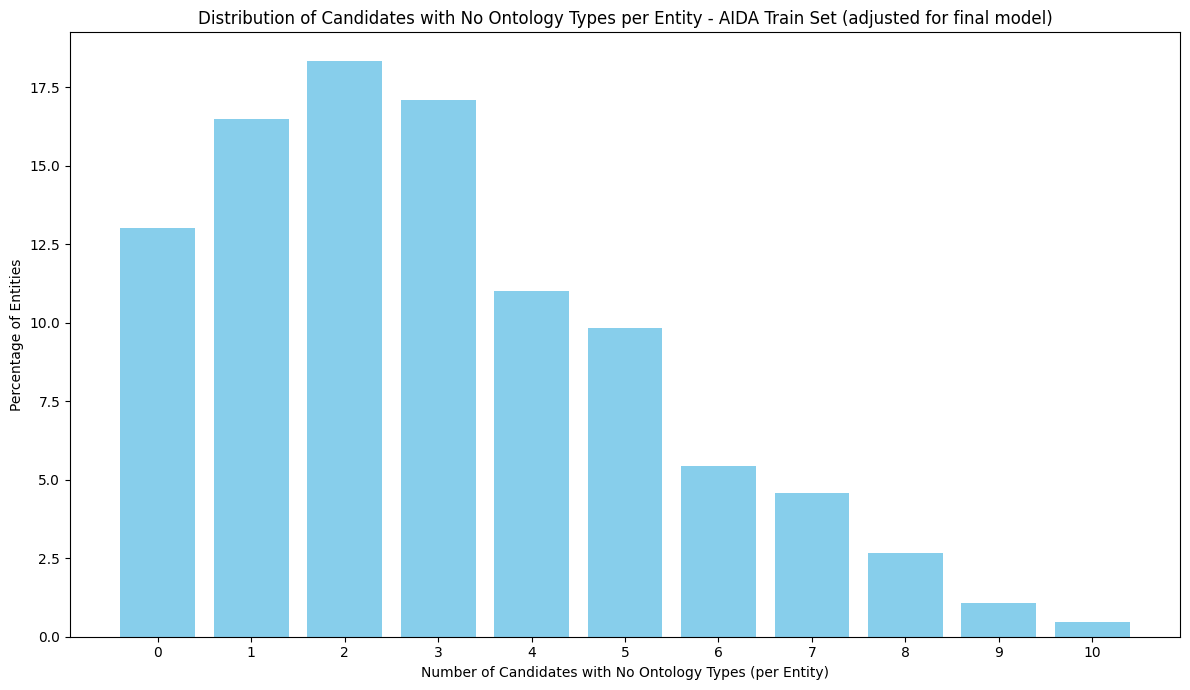

In [26]:
import json
import matplotlib.pyplot as plt
from collections import Counter

# Initialize variables to store combined results
all_named_entities = []

# Load and combine data from all three JSON files
for file_name, path in config_paths.items():
    print(f"Loading data from {file_name}...")
    with open(path, "r", encoding="utf-8") as file:
        data = json.load(file)
        print(f"\nLength of Named Entities in {file_name}: {len(data['named_entities'])}")
        all_named_entities.extend(data['named_entities'])


print(f"\nTotal number of named entities across all files: {len(all_named_entities)}")

# Analysis of combined data
total_candidates_overall = 0
count_no_ontology_overall = 0
entity_no_ontology_counts = []

for entity_prediction in all_named_entities:
    candidates = entity_prediction.get("candidates", [])
    no_ontology_count = 0
    total_candidates = len(candidates)
    total_candidates_overall += total_candidates
    for candidate in candidates:
        ontology_types = candidate.get("ontology_types", [])
        if not ontology_types:
            no_ontology_count += 1
            count_no_ontology_overall += 1
    entity_no_ontology_counts.append(no_ontology_count)

# Calculate the average percentage of candidates without ontology types
average_percent_no_ontology = (count_no_ontology_overall / total_candidates_overall) * 100 if total_candidates_overall > 0 else 0
print(f"\nAverage percentage of candidates without ontology types (across all files): {average_percent_no_ontology:.2f}%\n\n")

# Count the occurrences of each no_ontology_count
no_ontology_distribution = Counter(entity_no_ontology_counts)
total_entities = len(entity_no_ontology_counts)

# Prepare data for plotting
max_no_ontology = max(entity_no_ontology_counts) if entity_no_ontology_counts else 0
x_values = range(max_no_ontology + 1)
y_values = [(no_ontology_distribution[i] / total_entities) * 100 if total_entities > 0 else 0 for i in x_values]

# Visualization
plt.figure(figsize=(12, 7))
plt.bar(x_values, y_values, color="skyblue")
plt.xlabel("Number of Candidates with No Ontology Types (per Entity)")
plt.ylabel("Percentage of Entities")
plt.title("Distribution of Candidates with No Ontology Types per Entity - AIDA Train Set (adjusted for final model)")
plt.xticks(x_values)
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

#### Train Data - Score Candidates

In [73]:
import json
from datetime import datetime
from tqdm import tqdm
import pandas as pd

def score_candidate_predictions(predictions, dataset_name="Dataset", ner_model_name=None):
    """
    scorers candidates for each entity mention in the predictions using multiple scoring strategies,
    including NER-type embedding similarities.

    Parameters:
        predictions (List[Dict]): A list of annotated entries with entity candidates.
        dataset_name (str): Optional name of the dataset (for logging).
        ner_model_name (str): Name of the NER model used to determine the correct class descriptions.

    Returns:
        pd.DataFrame: Scored DataFrame with features for each candidate.
    """
    scored_data = []

    # Initialize NER-based scorers
    base_scorer = TypesEmbeddingScorer(ner_model_name=ner_model_name)
    topk_scorer = TopKTypesEmbeddingScorer(ner_model_name=ner_model_name)
    maxner_scorer = MaxNERTypesEmbeddingScorer(ner_model_name=ner_model_name)

    for entity in tqdm(predictions, desc=f"Scoring predictions for {dataset_name}"):
        context_text = entity["content"]
        entity_label = entity["entity_label"]
        start_position = entity["start_position"]
        end_position = entity["end_position"]
        candidates = entity.get("candidates", [])
        entity_probabilities = entity.get("probabilities", [])

        # Basic scores
        pop_scores = popularity_scorer.score_all(candidates)
        pos_scores_raw = list(range(1, len(candidates) + 1))
        normalized_pos_scores = position_scorer.normalize_score(pos_scores_raw)

        for i, candidate in enumerate(candidates):
            label = candidate["label"]
            comment = candidate.get("comment", "")
            ontology_types = candidate.get("ontology_types", [])
            
            # NER-ontology embedding scores (rounded to 3 decimal places)
            score_base = round(base_scorer.score_types_embedding(entity_probabilities, ontology_types), 3)
            score_topk = round(topk_scorer.score_types_embedding(entity_probabilities, ontology_types), 3)
            score_maxner = round(maxner_scorer.score_types_embedding(entity_probabilities, ontology_types), 3)


            score_lev = levenshtein_scorer.score(entity_label, label)
            score_ctx_bi = context_scorer_bi.score(context_text, comment)
            score_pop = pop_scores[i]
            score_pos = normalized_pos_scores[i]

            scored_data.append({
                "context_text": context_text,
                "entity_label": entity_label,
                "start_position": start_position,
                "end_position": end_position,
                "candidate_label": label,
                "candidate_uri": candidate["uri"],
                "score_levenshtein": score_lev,
                "score_context_bi": score_ctx_bi,
                "score_popularity": score_pop,
                "score_position": score_pos,
                "score_types_embedding": score_base,
                "score_topk_types_embedding": score_topk,
                "score_maxner_types_embedding": score_maxner,
            })

    return pd.DataFrame(scored_data)

def process_configs(config_paths, dataset_prefix=""):
    """
    Process and score candidate predictions for a given configuration.

    Parameters:
        config_paths (dict): A dictionary mapping model names to JSON file paths.
        dataset_prefix (str): A prefix used in the output CSV filename to distinguish datasets.
    """
    for model_key, path in config_paths.items():
        print(f"\nProcessing {dataset_prefix.upper()} - {model_key.upper()} dataset...")

        with open(path, "r", encoding="utf-8") as file:
            json_data = json.load(file)

        predictions = json_data["named_entities"]
        ner_model_name = json_data["configuration"].get("ner_model_name", None)

        scored_df = score_candidate_predictions(
            predictions,
            dataset_name=f"{dataset_prefix.upper()} - {model_key.upper()}",
            ner_model_name=ner_model_name
        )

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        csv_filename = f'{dataset_prefix}_scored_{model_key}_{timestamp}.csv'
        scored_df.to_csv(csv_filename, index=False)

        print(f"Saved scored data to {csv_filename}")

In [42]:
process_configs(config_paths, dataset_prefix="aida")


Processing CONLL dataset...
Using 4 classes
Using 4 classes
Using 4 classes


Scoring predictions for CONLL: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15771/15771 [1:05:41<00:00,  4.00it/s]


Saved scored data for CONLL to aida_train_with_NER_CONLL_scored_conll_20250424_175605.csv

Processing ONTONOTES dataset...
Using 11 classes
Using 11 classes
Using 11 classes


Scoring predictions for ONTONOTES: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11166/11166 [45:07<00:00,  4.12it/s]


Saved scored data for ONTONOTES to aida_train_with_NER_ONTONOTES_scored_ontonotes_20250424_184123.csv

Processing FEWNERD dataset...
Using 66 classes
Using 66 classes
Using 66 classes


Scoring predictions for FEWNERD: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10692/10692 [43:19<00:00,  4.11it/s]


Saved scored data for FEWNERD to aida_train_with_NER_FEWNERD_scored_fewnerd_20250424_192450.csv


#### Train Data - Import scored candidates from cached calculations 

In [33]:
df_train_aida_conll = pd.read_csv(output_calculations + "/aida_train_with_NER_CONLL_scored_conll_20250424_175605.csv")
df_train_aida_ontonotes = pd.read_csv(output_calculations + "/aida_train_with_NER_ONTONOTES_scored_ontonotes_20250424_184123.csv")
df_train_aida_fewnerd = pd.read_csv(output_calculations + "/aida_train_with_NER_FEWNERD_scored_fewnerd_20250424_192450.csv")

#### Analyse train data contents

In [34]:
df_train_aida_conll.describe()

,start_position,end_position,score_levenshtein,score_context_bi,score_popularity,score_position,score_types_embedding,score_topk_types_embedding,score_maxner_types_embedding
count,157639.000000,157639.000000,157639.000000,157639.000000,157639.000000,157639.000000,157639.000000,157639.000000,157639.000000
mean,550.817171,559.738796,0.470179,0.199199,0.379604,0.500000,0.109611,0.160564,0.160612
std,457.728087,457.851921,0.270223,0.176512,0.338808,0.319278,0.109678,0.157029,0.157049
min,0.000000,3.000000,0.000000,-0.208000,0.000000,0.000000,-0.035000,-0.035000,-0.035000
25%,172.000000,182.000000,0.250000,0.052000,0.075000,0.222000,0.000000,0.000000,0.000000
50%,441.000000,450.000000,0.460000,0.178000,0.289000,0.500000,0.069000,0.120000,0.120000
75%,844.000000,853.000000,0.650000,0.328000,0.635000,0.778000,0.206000,0.265000,0.265000
max,2217.000000,2223.000000,1.000000,0.843000,1.000000,1.000000,0.425000,0.523000,0.523000


In [35]:
df_train_aida_conll

,context_text,entity_label,start_position,end_position,candidate_label,candidate_uri,score_levenshtein,score_context_bi,score_popularity,score_position,score_types_embedding,score_topk_types_embedding,score_maxner_types_embedding
0,EU rejects German call to boycott British lamb...,German,11,17,German Empire,http://dbpedia.org/resource/German_Empire,0.63,0.072,0.566,1.000,0.095,0.148,0.148
1,EU rejects German call to boycott British lamb...,German,11,17,German language,http://dbpedia.org/resource/German_language,0.57,0.111,0.577,0.889,0.211,0.211,0.211
2,EU rejects German call to boycott British lamb...,German,11,17,Germany,http://dbpedia.org/resource/Germany,0.92,0.175,1.000,0.778,0.095,0.148,0.148
3,EU rejects German call to boycott British lamb...,German,11,17,West Germany,http://dbpedia.org/resource/West_Germany,0.67,0.098,0.637,0.667,0.095,0.148,0.148
4,EU rejects German call to boycott British lamb...,German,11,17,Nazi Germany,http://dbpedia.org/resource/Nazi_Germany,0.67,0.100,0.546,0.556,0.095,0.148,0.148
...,...,...,...,...,...,...,...,...,...,...,...,...,...
157634,SOCCER - ENGLISH SOCCER RESULTS . LONDON 1996-...,Lincoln,157,164,Lincoln Red Imps F.C.,http://dbpedia.org/resource/Lincoln_Red_Imps_F.C.,0.50,0.396,0.126,0.444,0.303,0.522,0.522
157635,SOCCER - ENGLISH SOCCER RESULTS . LONDON 1996-...,Lincoln,157,164,Republican Party (United States),http://dbpedia.org/resource/Republican_Party_(...,0.15,0.015,1.000,0.333,0.278,0.522,0.522
157636,SOCCER - ENGLISH SOCCER RESULTS . LONDON 1996-...,Lincoln,157,164,Lincolnshire,http://dbpedia.org/resource/Lincolnshire,0.74,0.235,0.544,0.222,0.085,0.224,0.224
157637,SOCCER - ENGLISH SOCCER RESULTS . LONDON 1996-...,Lincoln,157,164,University of Nebraska–Lincoln,http://dbpedia.org/resource/University_of_Nebr...,0.38,0.120,0.087,0.111,0.000,0.000,0.000


#### Merge three separate train datasets into one big training set

In [36]:
df_all = pd.concat([df_train_aida_conll, df_train_aida_ontonotes, df_train_aida_fewnerd], ignore_index=True)
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376105 entries, 0 to 376104
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   context_text                  376105 non-null  object 
 1   entity_label                  376105 non-null  object 
 2   start_position                376105 non-null  int64  
 3   end_position                  376105 non-null  int64  
 4   candidate_label               376071 non-null  object 
 5   candidate_uri                 376105 non-null  object 
 6   score_levenshtein             376105 non-null  float64
 7   score_context_bi              376105 non-null  float64
 8   score_popularity              376105 non-null  float64
 9   score_position                376105 non-null  float64
 10  score_types_embedding         376105 non-null  float64
 11  score_topk_types_embedding    376105 non-null  float64
 12  score_maxner_types_embedding  376105 non-nul

#### Flag the best candidate for each entity

In [37]:
df_with_best_flag = create_best_candidate_flag_grouped(df_all.copy(), golden_annotations)

In [38]:
df_with_best_flag.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376105 entries, 0 to 376104
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   context_text                  376105 non-null  object 
 1   entity_label                  376105 non-null  object 
 2   start_position                376105 non-null  int64  
 3   end_position                  376105 non-null  int64  
 4   candidate_label               376071 non-null  object 
 5   candidate_uri                 376105 non-null  object 
 6   score_levenshtein             376105 non-null  float64
 7   score_context_bi              376105 non-null  float64
 8   score_popularity              376105 non-null  float64
 9   score_position                376105 non-null  float64
 10  score_types_embedding         376105 non-null  float64
 11  score_topk_types_embedding    376105 non-null  float64
 12  score_maxner_types_embedding  376105 non-nul

In [46]:
df_with_best_flag.describe()

,start_position,end_position,score_levenshtein,score_context_bi,score_popularity,score_position,score_types_embedding,score_topk_types_embedding,score_maxner_types_embedding
count,376105.000000,376105.000000,376105.000000,376105.000000,376105.000000,376105.000000,376105.000000,376105.000000,376105.000000
mean,464.260704,473.170806,0.476020,0.203231,0.378694,0.500000,0.125648,0.186926,0.187658
std,381.460660,381.568611,0.269393,0.177241,0.338750,0.319279,0.124278,0.179699,0.180380
min,0.000000,3.000000,0.000000,-0.208000,0.000000,0.000000,-0.041000,-0.036000,-0.036000
25%,156.000000,165.000000,0.270000,0.055000,0.075000,0.222000,0.000000,0.000000,0.000000
50%,381.000000,391.000000,0.470000,0.184000,0.287000,0.500000,0.093000,0.156000,0.157000
75%,693.000000,701.000000,0.650000,0.333000,0.635000,0.778000,0.223000,0.305000,0.305000
max,2217.000000,2223.000000,1.000000,0.843000,1.000000,1.000000,0.678000,0.766000,0.767000


### Test Data Preparation 

#### Load Test Datasets from cached requests

In [25]:
evaluation_aida_config_paths = {
    "conll": output_requests + "/aida_test_full_span-marker-xlm-roberta-large-conllpp-doc-context_20250424_194021.json",
    "ontonotes": output_requests + "/aida_test_full_span-marker-roberta-large-ontonotes5_20250424_194112.json",
    "fewnerd": output_requests + "/aida_test_full_span-marker-bert-base-fewnerd-fine-super_20250424_194129.json",
}

evaluation_ace_config_paths = {
    "conll": output_requests + "/ace2004_full_span-marker-xlm-roberta-large-conllpp-doc-context_20250424_194152.json",
    "ontonotes": output_requests + "/ace2004_full_span-marker-roberta-large-ontonotes5_20250424_194220.json",
    "fewnerd": output_requests + "/ace2004_full_span-marker-bert-base-fewnerd-fine-super_20250424_194229.json",
}

#### Test Data - Score Candidates

In [55]:
process_configs(evaluation_aida_config_paths, dataset_prefix="aida")
process_configs(evaluation_ace_config_paths, dataset_prefix="ace")


Processing AIDA - CONLL dataset...
Using 4 classes
Using 4 classes
Using 4 classes


Scoring predictions for AIDA - CONLL: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3944/3944 [16:33<00:00,  3.97it/s]


Saved scored data to aida_scored_conll_20250424_200707.csv

Processing AIDA - ONTONOTES dataset...
Using 11 classes
Using 11 classes
Using 11 classes


Scoring predictions for AIDA - ONTONOTES: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2740/2740 [11:22<00:00,  4.02it/s]


Saved scored data to aida_scored_ontonotes_20250424_201839.csv

Processing AIDA - FEWNERD dataset...
Using 66 classes
Using 66 classes
Using 66 classes


...

Saved scored data to ace_scored_conll_20250424_203044.csv

Processing ACE - ONTONOTES dataset...
Using 11 classes
Using 11 classes
Using 11 classes


Scoring predictions for ACE - ONTONOTES: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 191/191 [00:45<00:00,  4.21it/s]


Saved scored data to ace_scored_ontonotes_20250424_203134.csv

Processing ACE - FEWNERD dataset...
Using 66 classes
Using 66 classes
Using 66 classes


Scoring predictions for ACE - FEWNERD: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 177/177 [00:40<00:00,  4.32it/s]

Saved scored data to ace_scored_fewnerd_20250424_203220.csv


#### Test Data - Import scored candidates from cached calculations

In [71]:
df_test_aida_conll = pd.read_csv(output_calculations + "/aida_scored_conll_20250424_200707.csv")
df_test_aida_ontonotes = pd.read_csv(output_calculations + "/aida_scored_ontonotes_20250424_201839.csv")
df_test_aida_fewnerd = pd.read_csv(output_calculations + "/aida_scored_fewnerd_20250424_202944.csv")

df_test_ace_conll = pd.read_csv(output_calculations + "/ace_scored_conll_20250424_203044.csv")
df_test_ace_ontonotes = pd.read_csv(output_calculations + "/ace_scored_ontonotes_20250424_203134.csv")
df_test_ace_fewnerd = pd.read_csv(output_calculations + "/ace_scored_fewnerd_20250424_203220.csv")

In [72]:
df_test_aida_conll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39430 entries, 0 to 39429
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   context_text                  39430 non-null  object 
 1   entity_label                  39430 non-null  object 
 2   start_position                39430 non-null  int64  
 3   end_position                  39430 non-null  int64  
 4   candidate_label               39425 non-null  object 
 5   candidate_uri                 39430 non-null  object 
 6   score_levenshtein             39430 non-null  float64
 7   score_context_bi              39430 non-null  float64
 8   score_popularity              39430 non-null  float64
 9   score_position                39430 non-null  float64
 10  score_types_embedding         39430 non-null  float64
 11  score_topk_types_embedding    39430 non-null  float64
 12  score_maxner_types_embedding  39430 non-null  float64
dtypes

### Candidate Selector - XGBoost Trainig and Evaluation

Train XGBoost model using each possible combination - use at least one of 4 contextual feature and at least one of the embedding-based features. 

Training process using each configuration is repeated 3 times to minimize randomness.

Evaluate the trained XGboost model using the six test datasets (each original test dataset has three versions, because three NER models were used). 

The average accuracy of predictions on these six test datasets should be maximised.

Top 10 models based on averaage prediction accuracy is saved on disk.

#### Helper functions

In [33]:
import json
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

def load_golden_annotations(filepath):
    """Load golden annotations from JSON file."""
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data.get("golden_annotations", [])


def annotate_with_best_candidate(df, golden_annotations):
    """Annotate the DataFrame with a flag for the best candidate URI."""
    best_uris = {}
    for entry in golden_annotations:
        entities = entry.get("entities", [])
        if isinstance(entities, list):
            for ent in entities:
                if all(k in ent for k in ["entity_label", "start_position", "end_position", "best_candidate_uri"]):
                    key = (entry["content"], ent["entity_label"], ent["start_position"], ent["end_position"])
                    best_uris[key] = ent["best_candidate_uri"]

    df["is_best_candidate"] = df.apply(
        lambda row: row["candidate_uri"] == best_uris.get((row["context_text"], row["entity_label"], row["start_position"], row["end_position"])),
        axis=1
    )
    return df


def build_evaluation_input(df, max_candidates=10, feature_columns=None):
    """Prepare model input arrays from the DataFrame."""
    if feature_columns is None:
        feature_columns = [
            'score_levenshtein',
            'score_context_bi',
            'score_position',
            'score_popularity',
            'score_types_embedding'
        ]

    grouped_features = []
    targets = []

    for key, group in df.groupby(['context_text', 'entity_label', 'start_position', 'end_position']):
        candidates = group[feature_columns].values
        if len(candidates) < max_candidates:
            pad = np.zeros((max_candidates - len(candidates), len(feature_columns)))
            candidates = np.vstack([candidates, pad])
        else:
            candidates = candidates[:max_candidates]

        best_idx = group['is_best_candidate'].values.argmax() if any(group['is_best_candidate']) else 0
        grouped_features.append(candidates.flatten().astype(np.float32))
        targets.append(best_idx)

    X = np.stack(grouped_features)
    y = np.array(targets, dtype=np.int64)
    return X, y


def analyse_dataset(df, golden_annotations, name, max_candidates=10, feature_columns=None):
    """Evaluate a single dataset and print metrics."""
    print(f"\n--- Evaluating: {name} ---")
    df_annotated = annotate_with_best_candidate(df.copy(), golden_annotations)

    # Convert the relevant columns of the predicted DataFrame into a set of tuples representing entities
    predicted_entities = set(df_annotated[['context_text', 'entity_label', 'start_position', 'end_position']].apply(tuple, axis=1))

    # Count how many entities from the predicted DataFrame are present in the golden annotations
    entities_in_golden = 0
    golden_entity_keys = set()
    for entry in golden_annotations:
        entities = entry.get("entities", [])
        if isinstance(entities, list):
            for ent in entities:
                if all(k in ent for k in ["entity_label", "start_position", "end_position", "best_candidate_uri"]):
                    key = (entry["content"], ent["entity_label"], ent["start_position"], ent["end_position"])
                    golden_entity_keys.add(key)

    for predicted_entity in predicted_entities:
        if predicted_entity in golden_entity_keys:
            entities_in_golden += 1

    total_golden_entities = len(golden_entity_keys)
    total_predicted_entities = len(predicted_entities)

    recall = (entities_in_golden / total_golden_entities) * 100 if total_golden_entities > 0 else 0
    print(f"Recall of NER model on {name}: {recall:.2f}%")

#### Training and Evaluation Loop

In [54]:
import pandas as pd
import numpy as np
import itertools
import joblib
import json
import os
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# === Constants ===
BASELINE_FEATURES = ['levenshtein', 'context_bi', 'popularity', 'position']
EMBEDDING_FEATURES = ['types_embedding', 'topk_types_embedding', 'maxner_types_embedding']

GROUP_KEYS = ['context_text', 'entity_label', 'start_position', 'end_position']
MAX_CANDIDATES = 10
REPEATS = 3
N_BEST_MODELS_TO_SAVE = 10

# === Helper Functions ===
def split_entity_level(df, test_size=0.2, seed=None):
    unique_entities = df[GROUP_KEYS].drop_duplicates()
    train_keys, val_keys = train_test_split(unique_entities, test_size=test_size)
    return df.merge(train_keys, on=GROUP_KEYS), df.merge(val_keys, on=GROUP_KEYS)

def build_grouped_features(df, feature_names):
    X, y = [], []
    for _, group in df.groupby(GROUP_KEYS):
        features = group[[f"score_{f}" for f in feature_names]].values
        if len(features) < MAX_CANDIDATES:
            padding = np.zeros((MAX_CANDIDATES - len(features), len(feature_names)))
            features = np.vstack([features, padding])
        else:
            features = features[:MAX_CANDIDATES]
        best_idx = group["is_best_candidate"].values.argmax()
        X.append(features.flatten().astype(np.float32))
        y.append(best_idx)
    return np.stack(X), np.array(y)

def train_and_evaluate(X_train, y_train, X_val, y_val):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("xgb", XGBClassifier(
            n_jobs=-1,
            num_class=MAX_CANDIDATES,
            eval_metric="mlogloss"
        ))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, zero_division=0)
    return pipeline, acc, report

def load_golden_annotations(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data.get("golden_annotations", [])

def annotate_with_best_candidate(df, golden_annotations):
    best_uris = {}
    for entry in golden_annotations:
        entities = entry.get("entities", [])
        for ent in entities:
            if all(k in ent for k in ["entity_label", "start_position", "end_position", "best_candidate_uri"]):
                key = (entry["content"], ent["entity_label"], ent["start_position"], ent["end_position"])
                best_uris[key] = ent["best_candidate_uri"]

    df["is_best_candidate"] = df.apply(
        lambda row: row["candidate_uri"] == best_uris.get((row["context_text"], row["entity_label"], row["start_position"], row["end_position"])),
        axis=1
    )
    return df

def build_evaluation_input(df, feature_columns):
    grouped_features, targets = [], []
    for _, group in df.groupby(GROUP_KEYS):
        candidates = group[feature_columns].values
        if len(candidates) < MAX_CANDIDATES:
            pad = np.zeros((MAX_CANDIDATES - len(candidates), len(feature_columns)))
            candidates = np.vstack([candidates, pad])
        else:
            candidates = candidates[:MAX_CANDIDATES]

        best_idx = group['is_best_candidate'].values.argmax() if any(group['is_best_candidate']) else 0
        grouped_features.append(candidates.flatten().astype(np.float32))
        targets.append(best_idx)

    return np.stack(grouped_features), np.array(targets)

def evaluate_external_dataset(df, golden_annotations, model, name, feature_names):
    print(f"\n--- Evaluating: {name} ---")
    df = annotate_with_best_candidate(df.copy(), golden_annotations)
    feature_columns = [f"score_{f}" for f in feature_names]
    X, y = build_evaluation_input(df, feature_columns)
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    report = classification_report(y, y_pred, zero_division=0)
    print(f"Accuracy: {acc:.4f}")
    return {
        "dataset": name,
        "accuracy": acc,
        "report": report
    }

# === Load External Test Sets ===
df_testsets = {
    "AIDA-CONLL": pd.read_csv(output_calculations + "/aida_scored_conll_20250424_200707.csv"),
    "AIDA-ONTONOTES": pd.read_csv(output_calculations + "/aida_scored_ontonotes_20250424_201839.csv"),
    "AIDA-FEWNERD": pd.read_csv(output_calculations + "/aida_scored_fewnerd_20250424_202944.csv"),
    "ACE-CONLL": pd.read_csv(output_calculations + "/ace_scored_conll_20250424_203044.csv"),
    "ACE-ONTONOTES": pd.read_csv(output_calculations + "/ace_scored_ontonotes_20250424_203134.csv"),
    "ACE-FEWNERD": pd.read_csv(output_calculations + "/ace_scored_fewnerd_20250424_203220.csv"),
}
golden_annotations = {
    "AIDA": load_golden_annotations(output_requests + "/aida_test_golden_annotations_with_candidates.json"),
    "ACE": load_golden_annotations(output_requests + "/ace_test_golden_annotations_with_candidates.json"),
}

# === Main Feature Selection and evaluation Process ===
def full_feature_selection(df_with_best_flag):
    all_results = []
    best_models = []  # 🔥 Store top N models sorted by avg_test_accuracy

    feature_combinations = []
    for r_base in range(1, len(BASELINE_FEATURES) + 1):
        for r_embed in range(1, len(EMBEDDING_FEATURES) + 1):
            for baseline_combo in itertools.combinations(BASELINE_FEATURES, r_base):
                for embedding_combo in itertools.combinations(EMBEDDING_FEATURES, r_embed):
                    combined = list(baseline_combo) + list(embedding_combo)
                    feature_combinations.append(combined)

    total_runs = len(feature_combinations) * REPEATS
    current_run = 1

    for selected_features in feature_combinations:
        label = f"selected_features---{'+'.join(selected_features)}"

        for repeat in range(REPEATS):
            print(f"▶️  [{current_run}/{total_runs}] Evaluating: {label} | Repeat {repeat+1}")
            current_run += 1

            df_train, df_val = split_entity_level(df_with_best_flag, test_size=0.2, seed=42 + repeat)
            try:
                X_train, y_train = build_grouped_features(df_train, selected_features)
                X_val, y_val = build_grouped_features(df_val, selected_features)
            except KeyError as e:
                print(f"⚠️ Missing features for {label}: {e}")
                continue

            model, val_acc, val_report = train_and_evaluate(X_train, y_train, X_val, y_val)

            # Evaluate on external datasets
            external_results = []
            sum_test_accuracy = 0
            for dataset_name, df_test in df_testsets.items():
                golden_key = "AIDA" if "AIDA" in dataset_name else "ACE"
                result = evaluate_external_dataset(
                    df_test,
                    golden_annotations[golden_key],
                    model,
                    name=dataset_name,
                    feature_names=selected_features
                )
                external_results.append(result)
                sum_test_accuracy += result['accuracy']

            avg_test_accuracy = sum_test_accuracy / len(df_testsets)

            model_result = {
                "features": selected_features,
                "repeat_idx": repeat,
                "val_accuracy": val_acc,
                "avg_test_accuracy": avg_test_accuracy,
                "external_results": external_results,
                "model": model,
            }
            all_results.append(model_result)

    # After all models trained and evaluated
    sorted_models = sorted(all_results, key=lambda x: x['avg_test_accuracy'], reverse=True)
    top_models = sorted_models[:N_BEST_MODELS_TO_SAVE]

    # Save top models
    for idx, result in enumerate(top_models):
        model_filename = f"best_xgb_model_{idx+1}_avgacc_{result['avg_test_accuracy']:.4f}.pkl"
        joblib.dump(result['model'], model_filename)
        print(f"✅ Saved {model_filename} with features {result['features']} (repeat {result['repeat_idx']}) and avg test acc {result['avg_test_accuracy']:.4f}")

    # Print final summary
    print("\n=== Top models Summary ===")
    for idx, result in enumerate(top_models):
        print(f"#{idx+1}: Features: {result['features']}, Repeat: {result['repeat_idx']}, Val Acc: {result['val_accuracy']:.4f}, Avg Test Acc: {result['avg_test_accuracy']:.4f}")

    return top_models


In [55]:
# === Start the Process ===
results, best_models = full_feature_selection(df_with_best_flag)

print("\n✅ Top Best Configurations:")
for idx, (acc, _, label, features, external_results, _) in enumerate(best_models[:N_BEST_MODELS_TO_SAVE]):
    print(f"\n#{idx+1}:")
    print(f"Label: {label}")
    print(f"Internal Validation Accuracy: {acc:.4f}")
    print(f"Selected Features: {features}")
    for res in external_results:
        print(f"- {res['dataset']}: Accuracy = {res['accuracy']:.4f}")

▶️  [1/315] Evaluating: selected_features---levenshtein+types_embedding | Repeat 1

--- Evaluating: AIDA-CONLL ---
Accuracy: 0.8278

--- Evaluating: AIDA-ONTONOTES ---
Accuracy: 0.7925

--- Evaluating: AIDA-FEWNERD ---
Accuracy: 0.8126

--- Evaluating: ACE-CONLL ---
Accuracy: 0.8626

--- Evaluating: ACE-ONTONOTES ---
Accuracy: 0.8586

--- Evaluating: ACE-FEWNERD ---
Accuracy: 0.8701
▶️  [2/315] Evaluating: selected_features---levenshtein+types_embedding | Repeat 2

--- Evaluating: AIDA-CONLL ---
Accuracy: 0.8245

--- Evaluating: AIDA-ONTONOTES ---
Accuracy: 0.7899

--- Evaluating: AIDA-FEWNERD ---
Accuracy: 0.7947

--- Evaluating: ACE-CONLL ---
Accuracy: 0.8531

--- Evaluating: ACE-ONTONOTES ---
Accuracy: 0.8534

--- Evaluating: ACE-FEWNERD ---
Accuracy: 0.8757
▶️  [3/315] Evaluating: selected_features---levenshtein+types_embedding | Repeat 3

--- Evaluating: AIDA-CONLL ---
Accuracy: 0.8245

--- Evaluating: AIDA-ONTONOTES ---
Accuracy: 0.7840

--- Evaluating: AIDA-FEWNERD ---
Accuracy:

ValueError: too many values to unpack (expected 2)